In [26]:
%pip install pandas
%pip install scikit-learn
%pip install tensorflow
%pip install matplotlib
%pip install imbalanced-learn
%env SCIPY_ARRAY_API=1


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
env: SCIPY_ARRAY_API=1


In [ ]:
# from model import build_cnn_rnn_model
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.utils.data_utils import load_and_preprocess_data
from src.model import build_weighted_model  # make sure this is imported
import csv
import pandas as pd
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE



In [28]:
# 1. Load and preprocess the dataset
X_train, X_test, y_train, y_test = load_and_preprocess_data("../data/dataset.csv")

In [29]:
# Oversampling

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(
    X_train.reshape(X_train.shape[0], -1), y_train
)

X_train_resampled = X_train_resampled.reshape(-1, X_train.shape[1], 1)

In [30]:
# 2. Build the model
model = build_weighted_model(input_shape=(X_train.shape[1], 1))

/Users/LucaZagaia/.pyenv/versions/3.10.13/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
# Early Stop
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [32]:
# compute class weights

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

In [33]:
# Model fit

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight={0: 1.0, 1:5.0},
    callbacks=[early_stop]
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9607 - loss: 0.5463 - recall: 0.0024 - val_accuracy: 0.9581 - val_loss: 0.2342 - val_recall: 0.1061
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9594 - loss: 0.3735 - recall: 0.2213 - val_accuracy: 0.9444 - val_loss: 0.1894 - val_recall: 0.5000
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9506 - loss: 0.3092 - recall: 0.4189 - val_accuracy: 0.9531 - val_loss: 0.1506 - val_recall: 0.3939
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9509 - loss: 0.2818 - recall: 0.5336 - val_accuracy: 0.9287 - val_loss: 0.1957 - val_recall: 0.6061
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9489 - loss: 0.2883 - recall: 0.5393 - val_accuracy: 0.9456 - val_loss: 0.1689 - val_recall: 0.5455
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9551 - loss: 0.2861 - recall: 0.5122 - val_accuracy: 0.9450 - val_loss: 0.1686 - val_recall: 0.530

In [34]:
# 4. Evaluate
loss, accuracy, recall = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Recall: {recall:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9606 - loss: 0.1150 - recall: 0.3607
Test Accuracy: 0.9650
Test Recall: 0.4262


In [35]:
model.save("../results/cnn_rnn_model.h5")

with open("../results/metrics.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["Loss", "Accuracy"])
    writer.writerow([loss, accuracy])

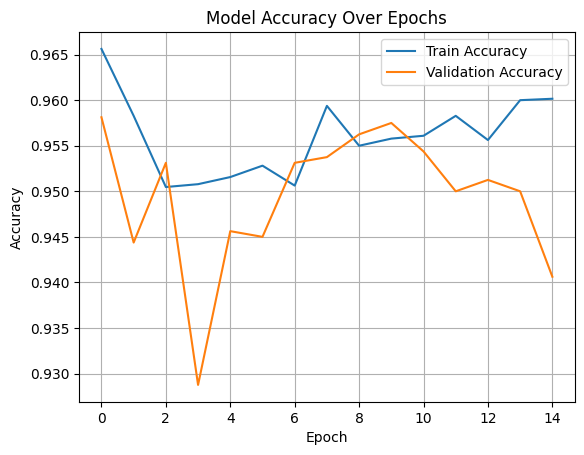

In [36]:


plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


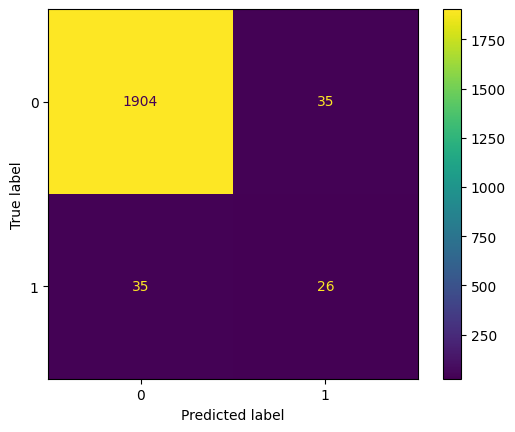

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = model.predict(X_test).flatten()
y_pred_labels = np.where(y_pred > 0.5, 1, 0)

cm = confusion_matrix(y_test, y_pred_labels)
ConfusionMatrixDisplay(cm).plot()

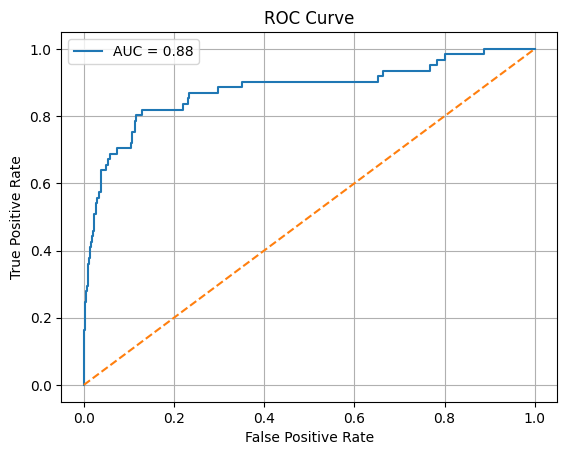

In [38]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
results = pd.DataFrame({
    "Prediction": y_pred_labels,
    "True Label": y_test.reset_index(drop=True)
})
results.to_csv("../results/predictions.csv", index=False)

In [40]:
recall = recall_score(y_test, y_pred_labels)
print(f"Failure recall: {recall:.4f}")

Failure recall: 0.4262


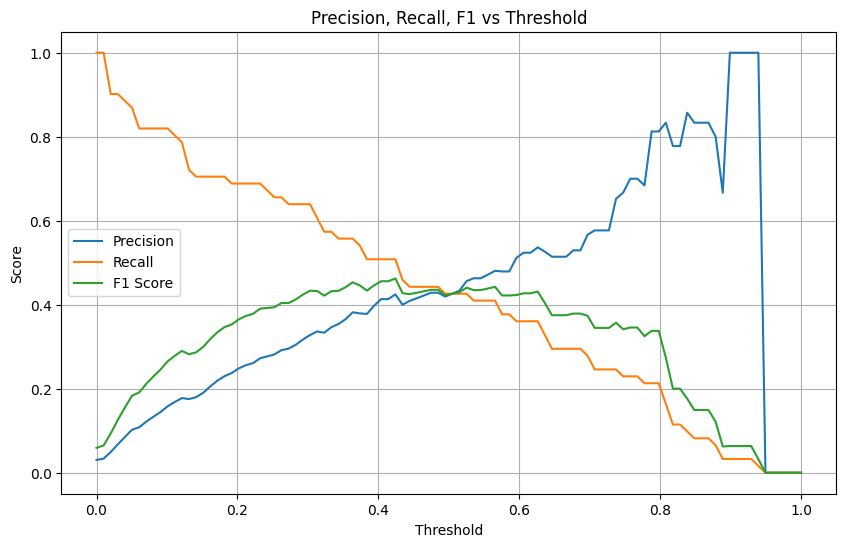

✅ Best threshold: 0.42
📈 Best F1 Score: 0.4627


In [41]:
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import warnings

thresholds = np.linspace(0, 1, 100)
precisions = []
recalls = []
f1s = []

for t in thresholds:
    y_pred_labels = (y_pred > t).astype(int)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        p = precision_score(y_test, y_pred_labels, zero_division=0)
        r = recall_score(y_test, y_pred_labels)
        f1 = f1_score(y_test, y_pred_labels)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f1)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, f1s, label='F1 Score')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


# Define thresholds to sweep through
thresholds = np.linspace(0, 1, 100)
best_threshold = 0
best_f1 = 0

for t in thresholds:
    y_pred_labels = (y_pred > t).astype(int)
    f1 = f1_score(y_test, y_pred_labels, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"✅ Best threshold: {best_threshold:.2f}")
print(f"📈 Best F1 Score: {best_f1:.4f}")

# Optional: apply the best threshold for final evaluation
y_pred_best = (y_pred > best_threshold).astype(int)

In [42]:
from sklearn.metrics import classification_report, confusion_matrix

threshold = 0.36
y_pred_labels = (y_pred > threshold).astype(int)

# Compute precision-recall pairs
prec, rec, thresholds = precision_recall_curve(y_test, y_pred)

# # Plot
# plt.plot(thresholds, prec[:-1], label='Precision')
# plt.plot(thresholds, rec[:-1], label='Recall')
# plt.xlabel("Threshhold")
# plt.legend()
# plt.grid(True)
# plt.title("Precision-Recall vs Threshhold")
# plt.show()

# Evaluate
print(confusion_matrix(y_test, y_pred_labels))
print(classification_report(y_test, y_pred_labels, digits=4))

[[1882   57]
 [  27   34]]
              precision    recall  f1-score   support

           0     0.9859    0.9706    0.9782      1939
           1     0.3736    0.5574    0.4474        61

    accuracy                         0.9580      2000
   macro avg     0.6797    0.7640    0.7128      2000
weighted avg     0.9672    0.9580    0.9620      2000

